In [25]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
dataset_path = "/mnt/e/Deep Learning/data/aclImdb_v1_extracted/aclImdb"
dataset_dir = os.listdir(dataset_path)
dataset_dir

['imdb.vocab', 'imdbEr.txt', 'README', 'test', 'train']

In [3]:
train_path = os.path.join(dataset_path, 'train')
test_path = os.path.join(dataset_path, 'test')

train_dir = os.listdir(train_path)
test_dir = os.listdir(test_path)

train_dir

['labeledBow.feat',
 'neg',
 'pos',
 'unsupBow.feat',
 'urls_neg.txt',
 'urls_pos.txt',
 'urls_unsup.txt']

In [4]:
train_dir_pos_path = os.path.join(train_path, 'pos')
train_dir_neg_path = os.path.join(train_path, 'neg')

test_dir_pos_path = os.path.join(test_path, 'pos')
test_dir_neg_path = os.path.join(test_path, 'neg')

print(f"Number of txt files in train positive directory: {len(os.listdir(train_dir_pos_path))}")
print(f"Number of txt files in train negative directory: {len(os.listdir(train_dir_neg_path))}")
print(f"Number of txt files in validation positive directory: {len(os.listdir(test_dir_pos_path))}")
print(f"Number of txt files in validation negative directory: {len(os.listdir(test_dir_neg_path))}")


Number of txt files in train positive directory: 12500
Number of txt files in train negative directory: 12500
Number of txt files in validation positive directory: 12500
Number of txt files in validation negative directory: 12500


In [5]:
with open("/mnt/e/Deep Learning/data/aclImdb_v1_extracted/aclImdb/train/pos/0_9.txt", "r") as f:
    txt = f.read()
    print(txt)

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


In [6]:
raw_train_ds = tf.keras.utils.text_dataset_from_directory(train_path, 
                                                          batch_size=32, 
                                                          subset='training', 
                                                          validation_split=0.2, 
                                                          seed=42)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(train_path,
                                                        batch_size=32,
                                                        subset='validation',
                                                        validation_split=0.2,
                                                        seed=42)

raw_test_ds = tf.keras.utils.text_dataset_from_directory(test_path,
                                                        batch_size=32,
                                                        seed=42)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


W0000 00:00:1779165726.068026    1920 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


In [7]:
tf.data.experimental.cardinality(raw_train_ds).numpy()

np.int64(625)

In [8]:
tf.data.experimental.cardinality(raw_val_ds).numpy()

np.int64(157)

In [9]:
for texts, labels in raw_train_ds.take(1):
    text = texts[0].numpy()
    label = labels[0]
    print(text)
    print(f"Class Name is: {raw_train_ds.class_names[label]}")

b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Class Name is: neg


In [10]:
import re
import string

In [11]:
def custom_standardization(input_data):
    lower_case = tf.strings.lower(input_data)
    striped_html = tf.strings.regex_replace(lower_case, "<br />", ' ')
    striped_punc = tf.strings.regex_replace(striped_html, '[%s]' % re.escape(string.punctuation), '')
    
    return striped_punc

In [12]:
max_features = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(standardize=custom_standardization,
                                                    max_tokens=max_features,
                                                    output_mode='int',
                                                    output_sequence_length=sequence_length
                                                    )


In [13]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [14]:
vectorize_layer("Hello world! This is a test.")

<tf.Tensor: shape=(250,), dtype=int64, numpy=
array([5128,  182,   11,    7,    4, 2179,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
     

In [15]:
vectorize_layer.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('and'),
 np.str_('a'),
 np.str_('of'),
 np.str_('to'),
 np.str_('is'),
 np.str_('in'),
 np.str_('it'),
 np.str_('i'),
 np.str_('this'),
 np.str_('that'),
 np.str_('was'),
 np.str_('as'),
 np.str_('for'),
 np.str_('with'),
 np.str_('movie'),
 np.str_('but'),
 np.str_('film'),
 np.str_('on'),
 np.str_('not'),
 np.str_('you'),
 np.str_('are'),
 np.str_('his'),
 np.str_('have'),
 np.str_('be'),
 np.str_('he'),
 np.str_('one'),
 np.str_('its'),
 np.str_('all'),
 np.str_('at'),
 np.str_('by'),
 np.str_('an'),
 np.str_('they'),
 np.str_('from'),
 np.str_('who'),
 np.str_('so'),
 np.str_('like'),
 np.str_('her'),
 np.str_('just'),
 np.str_('or'),
 np.str_('about'),
 np.str_('has'),
 np.str_('out'),
 np.str_('if'),
 np.str_('some'),
 np.str_('there'),
 np.str_('what'),
 np.str_('good'),
 np.str_('more'),
 np.str_('when'),
 np.str_('very'),
 np.str_('even'),
 np.str_('my'),
 np.str_('she'),
 np.str_('up'),
 np.str_('no'),
 np.str_('time'),
 np.str_('would

In [16]:
for text, labels in raw_train_ds.take(1):
    print(f"Shape of texts: {text.shape}")

Shape of texts: (32,)


In [17]:
def vectorize_text(texts, labels):
    texts = tf.expand_dims(texts, -1)   #(32, 1)
    return vectorize_layer(texts), labels

In [18]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [19]:
train_ds = train_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)

In [20]:
embedding_dim = 16

In [35]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,)),
    tf.keras.layers.Embedding(max_features, embedding_dim),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,017 (625.07 KB)

 Trainable params: 160,017 (625.07 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3), 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['acc'])

In [38]:
num_epochs = 30

history = model.fit(train_ds, validation_data=val_ds, epochs=num_epochs, batch_size=64)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.5155 - loss: 0.6600 - val_acc: 0.5852 - val_loss: 0.6095
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.6773 - loss: 0.5474 - val_acc: 0.7118 - val_loss: 0.4982
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.7857 - loss: 0.4476 - val_acc: 0.7580 - val_loss: 0.4307
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.8298 - loss: 0.3842 - val_acc: 0.7974 - val_loss: 0.3864
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8559 - loss: 0.3417 - val_acc: 0.8024 - val_loss: 0.3664
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8709 - loss: 0.3114 - val_acc: 0.8170 - val_loss: 0.3470
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.8821 - loss: 0.2882 - val_acc: 0.8234 - val_loss: 0.3370
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.8906 - loss: 0.2682 - val_acc: 0.8336 - val_loss: 0.3253
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

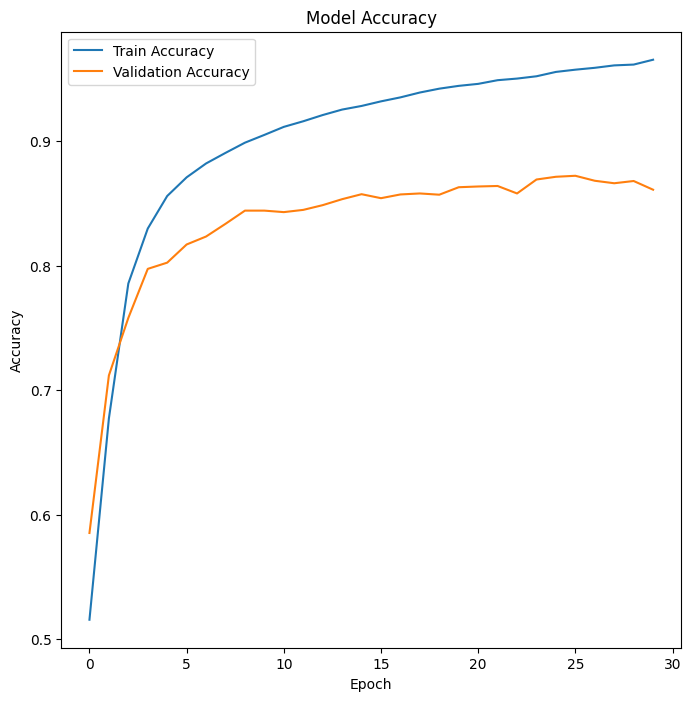

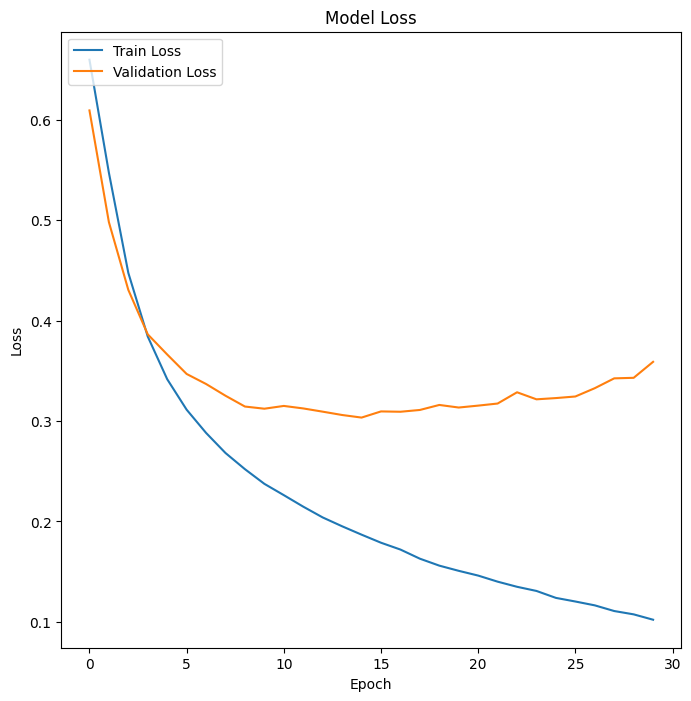

In [39]:

import matplotlib.pyplot as plt
import numpy as np



plt.figure(figsize=(8, 8))

plt.plot(np.arange(30), history.history['acc'])
plt.plot(np.arange(30), history.history['val_acc'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train Accuracy", "Validation Accuracy"], loc="upper left")
plt.show()

plt.figure(figsize=(8, 8))
plt.plot(np.arange(30), history.history['loss'])
plt.plot(np.arange(30), history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train Loss", "Validation Loss"], loc="upper left")
plt.show()
